In [1]:
#%pip install pandas
#%pip install torch
#%pip install matplotlib
#%pip install scikit-learn
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv('machines_sample_400.csv')
df.head()


df["ds"] = pd.to_datetime(df["time_stamp"], unit="s")
df = df.sort_values(["machine_id", "ds"])

dfs_resampled = []

# raggruppo per macchina
for machine_id, df_m in df.groupby('machine_id'):
    # raggruppo per intervalli di 5min e interpolo i valori mancanti
    df_m = df_m.set_index('ds').sort_index()
    numeric_cols = df_m.select_dtypes(include='number').columns
    df_m_resampled = df_m[numeric_cols].resample('5min').mean()
    df_m_resampled = df_m_resampled.interpolate(method='linear', limit_direction='both')
    
    df_m_resampled['machine_id'] = machine_id
    df_m_resampled = df_m_resampled.reset_index()
    dfs_resampled.append(df_m_resampled)

df_resampled = pd.concat(dfs_resampled, ignore_index=True)

# normalizzazione della colonna target della previsione (media 0, stdv 1)
cpu_mean = df_resampled["cpu_util_percent"].mean()
cpu_std  = df_resampled["cpu_util_percent"].std()
df_resampled["cpu_norm"] = (df_resampled["cpu_util_percent"] - cpu_mean) / cpu_std

print("mean",cpu_mean)
print("std", cpu_std)



mean 37.661774760007766
std 15.296503574604664


In [3]:
df.head()

,machine_id,time_stamp,cpu_util_percent,mem_util_percent,mem_gps,mkpi,net_in,net_out,disk_io_percent,ds
4007461,m_1,10,13,84,NaN,NaN,32.46,23.09,1,1970-01-01 00:00:10
1276857,m_1,130,11,85,NaN,NaN,32.47,23.09,1,1970-01-01 00:02:10
1276858,m_1,190,9,84,NaN,NaN,32.47,23.09,1,1970-01-01 00:03:10
1276859,m_1,260,10,84,NaN,NaN,32.47,23.09,2,1970-01-01 00:04:20
4007462,m_1,310,12,85,NaN,NaN,32.47,23.09,2,1970-01-01 00:05:10


In [4]:
class MultiStepCPUDataset(Dataset):
    def __init__(self, df, input_window=30, horizon=10):
        # per ogni macchina estraggo la finestra di input e il target, le cui dimensioni dipendono dai valori che passo alla classe
        # tensori del tipo 
        # x: [num_samples, input_window, 1] dove 1 è il num di feature
        # y: [num_samples, horizon]
        self.X = []
        self.y = []

        for _, df_m in df.groupby("machine_id"):
            series = df_m["cpu_norm"].values

            if len(series) < input_window + horizon:
                continue

            for i in range(len(series) - input_window - horizon):
                self.X.append(series[i:i+input_window])
                self.y.append(series[i+input_window:i+input_window+horizon])

        self.X = torch.tensor(np.array(self.X), dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [5]:
INPUT_TIME=2*60
INPUT_WINDOW = int(INPUT_TIME/5)
HORIZON_TIME=1*60
HORIZON = int(HORIZON_TIME/5)
BATCH_SIZE = 512

dataset = MultiStepCPUDataset(df_resampled, INPUT_WINDOW, HORIZON)

indices = np.arange(len(dataset))
train_idx, val_idx = train_test_split(indices, test_size=0.2, shuffle=True)

train_ds = torch.utils.data.Subset(dataset, train_idx)
val_ds   = torch.utils.data.Subset(dataset, val_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)


In [6]:
class LSTMForecast(nn.Module):
    def __init__(self, hidden=256, layers=3, horizon=30):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden,
            num_layers=layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden, horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)


In [7]:
INPUT_TIME=2*60
INPUT_WINDOW = int(INPUT_TIME/5)
HORIZON_TIME=1*60
HORIZON = int(HORIZON_TIME/5)
BATCH_SIZE = 512
def forecast_cpu(model, cpu_series, window=30):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    x = torch.tensor(cpu_series[-window:], dtype=torch.float32)
    x = ((x - cpu_mean) / cpu_std).unsqueeze(0).unsqueeze(-1).to(device)

    with torch.no_grad():
        pred = model(x).cpu().numpy()[0]

    return pred * cpu_std + cpu_mean


In [ ]:
# carica modello
model = torch.load(
    "lstm_cpu_model_full_no_att.pt",
    weights_only=False,
)
model


LSTMForecast(
  (lstm): LSTM(1, 256, num_layers=3, batch_first=True)
  (fc): Linear(in_features=256, out_features=12, bias=True)
)

In [11]:
data = pd.read_json('data.json')
series = pd.DataFrame(data["values"].tolist(), columns=["time_stamp", "cpu_util_percent"])
series["cpu_util_percent"] = pd.to_numeric(series["cpu_util_percent"], errors='coerce')
series["ds"] = pd.to_datetime(series["time_stamp"], unit="s")

# Resampling e Interpolazione
series = (
    series[['ds', 'cpu_util_percent']]
    .set_index('ds')
    .sort_index()
    .resample('5min')
    .mean()
    .interpolate(method='linear', limit_direction='both')
)
series


,cpu_util_percent
ds,
2026-03-05 17:35:00,36.540556
2026-03-05 17:40:00,46.591898
2026-03-05 17:45:00,41.486243
2026-03-05 17:50:00,27.650456
2026-03-05 17:55:00,51.905247
2026-03-05 18:00:00,54.915437
2026-03-05 18:05:00,52.617576
2026-03-05 18:10:00,51.838583
2026-03-05 18:15:00,50.639435


In [24]:
WINDOW_ID = 5
start = WINDOW_ID
end_x = start + INPUT_WINDOW
# 2. Preparazione dei segmenti (X e Y reali)
# Assumiamo di voler testare il modello su una finestra specifica
x_input = series.iloc[:INPUT_WINDOW]
y_real = series.iloc[INPUT_WINDOW : INPUT_WINDOW + HORIZON]

# 3. Predizione (Usa .values per evitare il FutureWarning di pandas)
future_cpu = forecast_cpu(model, x_input['cpu_util_percent'].values, INPUT_WINDOW)

# 4. Creazione indice temporale per la predizione (Risolve il ValueError delle dimensioni)
# Generiamo un range di date che parte dopo l'ultimo punto di X
forecast_index = pd.date_range(
    start=x_input.index[-1] + pd.Timedelta(minutes=1), 
    periods=len(future_cpu), 
    freq='5min'
)

print("Lunghezza previsione generata:", len(forecast_index))

Lunghezza previsione generata: 12


In [25]:
# Carica il JSON da file usando pandas
data = pd.read_json('data.json')

# Crea la serie temporale dai valori del JSON
timestamps = pd.to_datetime(data['values'].apply(lambda x: x[0]), unit='s')
cpu_values = data['values'].apply(lambda x: float(x[1]))

# Crea il DataFrame della serie
series_from_json = pd.DataFrame({
    'cpu_util_percent': cpu_values.values
}, index=timestamps)

series_from_json
series_from_json = series_from_json.sort_index()

# Resample a 5 minuti se necessario
series_from_json = series_from_json.resample('5min').mean().interpolate(method='linear', limit_direction='both')

print(f"Serie caricata: {len(series_from_json)} punti")
print(series_from_json.head())



Serie caricata: 42 punti
                     cpu_util_percent
values                               
2026-03-05 17:15:00         31.745833
2026-03-05 17:20:00         48.149000
2026-03-05 17:25:00         37.537389
2026-03-05 17:30:00         43.357278
2026-03-05 17:35:00         24.954278



Input window: 24 punti
Target window: 12 punti
Predicted window: 12 punti


/tmp/ipykernel_1496/3183925955.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = torch.tensor(cpu_series[-window:], dtype=torch.float32)


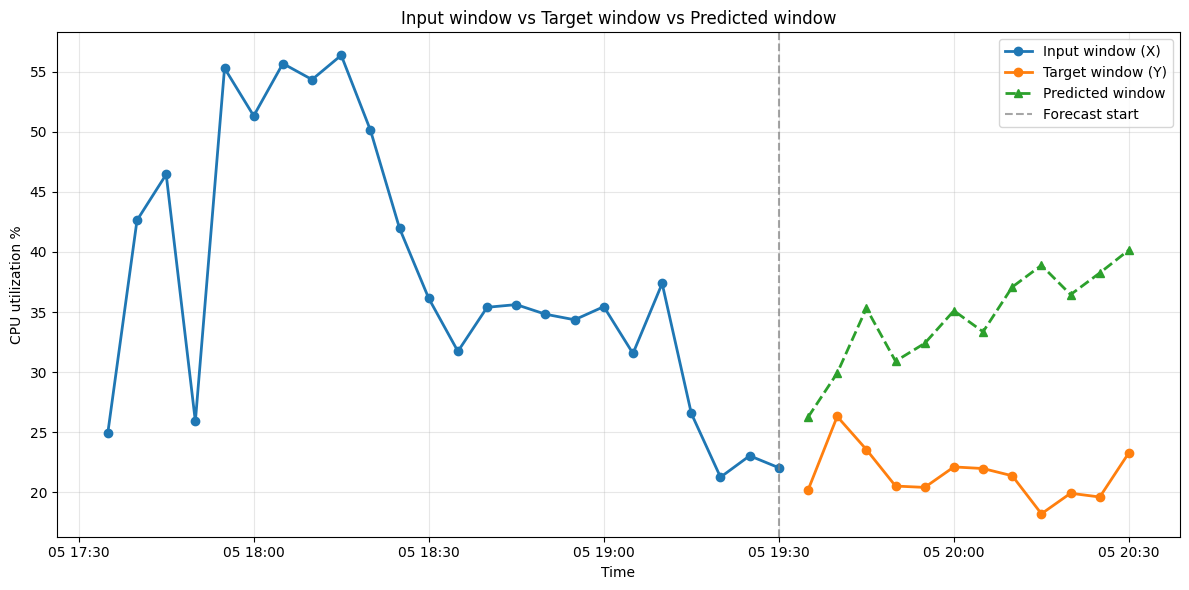

In [32]:


# Definisci i parametri (devono corrispondere al training)
INPUT_TIME = 2*60
INPUT_WINDOW = int(INPUT_TIME/5)
HORIZON_TIME = 1*60
HORIZON = int(HORIZON_TIME/5)
# Seleziona quale finestra usare per il test
WINDOW_ID = 4

# Verifica che ci siano abbastanza dati
if len(series_from_json) < WINDOW_ID + INPUT_WINDOW + HORIZON:
    print(f"ATTENZIONE: servono almeno {WINDOW_ID + INPUT_WINDOW + HORIZON} punti, ne hai {len(series_from_json)}")
else:
    # Estrai input window e target window
    start = WINDOW_ID
    x = series_from_json[start:start + INPUT_WINDOW]
    y = series_from_json[start + INPUT_WINDOW:start + INPUT_WINDOW + HORIZON]
    
    # Fai la predizione
    future_cpu = forecast_cpu(model, x['cpu_util_percent'], INPUT_WINDOW)
    
    print(f"\nInput window: {len(x)} punti")
    print(f"Target window: {len(y)} punti")
    print(f"Predicted window: {len(future_cpu)} punti")
    
    # Crea il grafico
    plt.figure(figsize=(12, 6))
    
    plt.plot(x.index, x["cpu_util_percent"], label="Input window (X)", marker="o", linewidth=2)
    plt.plot(y.index, y["cpu_util_percent"], label="Target window (Y)", marker="o", linewidth=2)
    plt.plot(y.index, future_cpu, label="Predicted window", marker="^", linewidth=2, linestyle='--')
    
    plt.axvline(
        x.index[-1],
        color="gray",
        linestyle="--",
        alpha=0.7,
        label="Forecast start"
    )
    
    plt.title("Input window vs Target window vs Predicted window")
    plt.xlabel("Time")
    plt.ylabel("CPU utilization %")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()